# House Price Prediction

## Objective

Predict house prices using Machine Learning without using scikit learn.

Algorithm: 
- Simple Linear Regression
Libraries:
- Numpy
- Pandas
- Matplotlib
- seaborn 

Developer: 
Sahil Bhayre

## Dataset Information

- Dataset: Housing.csv
- Samples: 545
- Features: 13
- Target Variable: Price

## 1. Import Libraries:

In [2]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns  

## 2. Load Dataset

In [3]:
df = pd.read_csv("Housing.csv")

## 3. Dataset Overview

In [4]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420.0,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960.0,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960.0,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500.0,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420.0,4,1,2,yes,yes,NaN,no,yes,2,no,unfurnished


In [5]:
df.tail()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
540,1820000,3000.0,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400.0,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620.0,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910.0,3,1,1,no,no,no,no,no,0,no,furnished
544,1750000,3850.0,3,1,2,yes,no,no,no,no,0,no,unfurnished


In [6]:
df.shape

(545, 13)

In [7]:
df.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')

## 4. Exploratory Data Analysis

### 4.1 Basic info

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   price             545 non-null    int64  
 1   area              544 non-null    float64
 2   bedrooms          545 non-null    int64  
 3   bathrooms         545 non-null    int64  
 4   stories           545 non-null    int64  
 5   mainroad          545 non-null    object 
 6   guestroom         545 non-null    object 
 7   basement          544 non-null    object 
 8   hotwaterheating   545 non-null    object 
 9   airconditioning   545 non-null    object 
 10  parking           545 non-null    int64  
 11  prefarea          545 non-null    object 
 12  furnishingstatus  545 non-null    object 
dtypes: float64(1), int64(5), object(7)
memory usage: 55.5+ KB


### 4.2 Check null values

In [9]:
df.isnull().sum()

price               0
area                1
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            1
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [10]:
df[df.isnull().any(axis=1)]

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
4,11410000,7420.0,4,1,2,yes,yes,NaN,no,yes,2,no,unfurnished
24,8575000,NaN,3,2,2,yes,no,no,no,yes,2,no,furnished


### 4.3 Statistical Summary

In [11]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,544.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5143.832721,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2166.474646,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3596.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4580.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


### 4.4 Check duplicate row

In [12]:
df.duplicated().sum()

np.int64(0)

### 4.5 Distribution of Numerical feature

array([[<Axes: title={'center': 'price'}>,
        <Axes: title={'center': 'area'}>],
       [<Axes: title={'center': 'bedrooms'}>,
        <Axes: title={'center': 'bathrooms'}>],
       [<Axes: title={'center': 'stories'}>,
        <Axes: title={'center': 'parking'}>]], dtype=object)

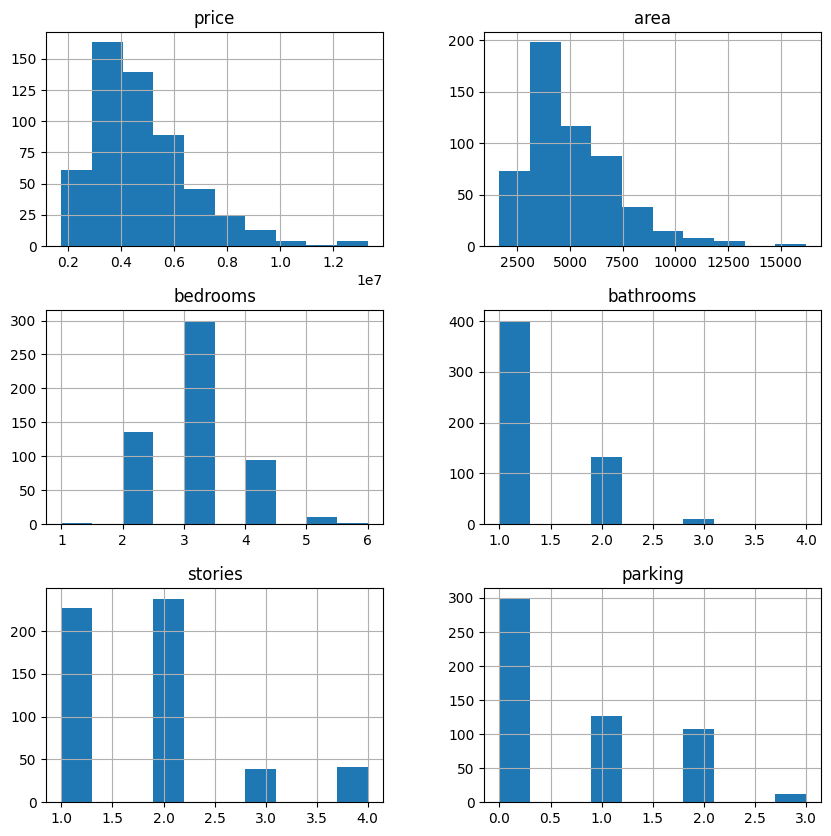

In [13]:
df.hist(figsize=(10, 10))

### 4.6 Correlation Analysis

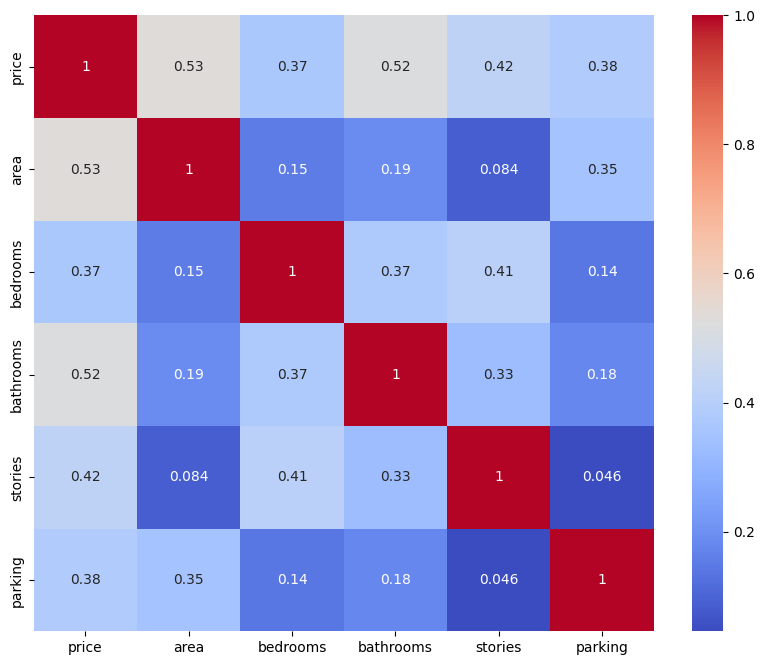

In [14]:
df.corr(numeric_only=True)
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.show()

###  4.7 Target Variable Analysis

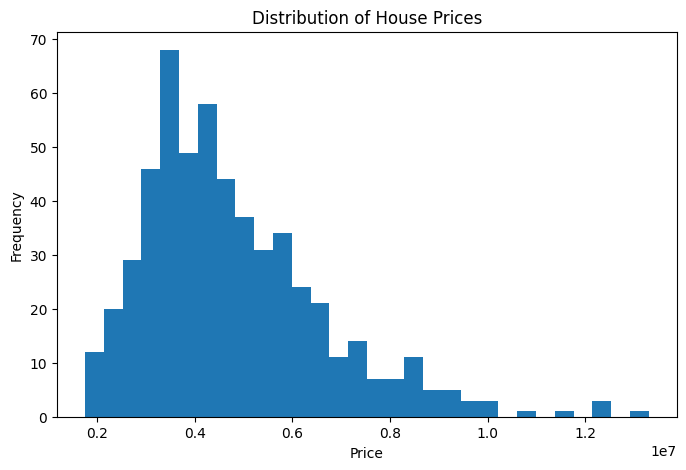

In [15]:
plt.figure(figsize=(8,5))
plt.hist(df["price"], bins=30)
plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

### 4.8 Scatter Plot

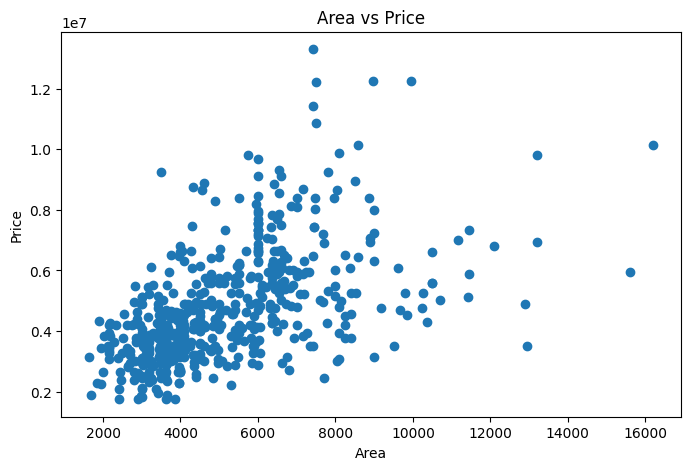

In [16]:
plt.figure(figsize=(8,5))

plt.scatter(df["area"], df["price"])

plt.xlabel("Area")
plt.ylabel("Price")

plt.title("Area vs Price")

plt.show()

### 4.9 Outlier Detection

<Axes: xlabel='area'>

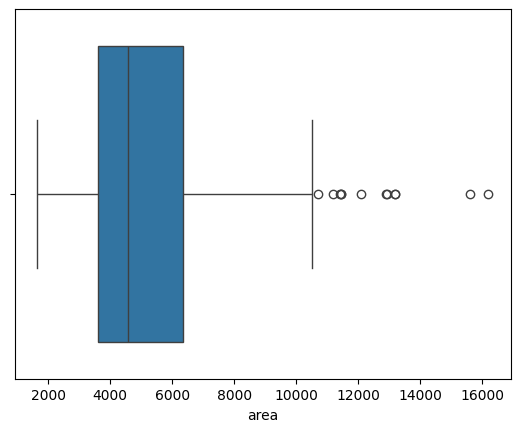

In [17]:
sns.boxplot(x=df['area'])

### KEY FINDING from EDA
- No duplicate rows
- 2 missing value in column basement and area both have 1-1
- price and area are right skewed
- price and area contain potential outliers that should be investigated.
- area and bathrooms have the strongest positive correlation with price.

## 5. Data Preprocessing or Data Cleaning

### 5.1 Remove duplicate value

In [18]:
df['area'] = df['area'].fillna(df['area'].median())

In [19]:
df['basement'] = df['basement'].fillna(df['basement'].mode()[0])

In [20]:
df.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420.0,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960.0,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960.0,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500.0,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420.0,4,1,2,yes,yes,no,no,yes,2,no,unfurnished
5,10850000,7500.0,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580.0,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200.0,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100.0,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750.0,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


### 5.2 Handle Categorical Features

In [21]:
df.select_dtypes(include='object')

,mainroad,guestroom,basement,hotwaterheating,airconditioning,prefarea,furnishingstatus
0,yes,no,no,no,yes,yes,furnished
1,yes,no,no,no,yes,no,furnished
2,yes,no,yes,no,no,yes,semi-furnished
3,yes,no,yes,no,yes,yes,furnished
4,yes,yes,no,no,yes,no,unfurnished
...,...,...,...,...,...,...,...
540,yes,no,yes,no,no,no,unfurnished
541,no,no,no,no,no,no,semi-furnished
542,yes,no,no,no,no,no,unfurnished
543,no,no,no,no,no,no,furnished


In [22]:
binary_cols = [
    'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea'
]

for col in binary_cols:
    df[col] = df[col].map({'yes': 1, 'no': 0})

In [23]:
df = pd.get_dummies(
    df, 
    columns=['furnishingstatus'],
    drop_first = True, 
    dtype = int
)

In [24]:
dummy_cols = [
    "furnishingstatus_semi-furnished",
    "furnishingstatus_unfurnished"
]

df[dummy_cols] = df[dummy_cols].astype(int)

In [25]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420.0,4,2,3,1,0,0,0,1,2,1,0,0
1,12250000,8960.0,4,4,4,1,0,0,0,1,3,0,0,0
2,12250000,9960.0,3,2,2,1,0,1,0,0,2,1,1,0
3,12215000,7500.0,4,2,2,1,0,1,0,1,3,1,0,0
4,11410000,7420.0,4,1,2,1,1,0,0,1,2,0,0,1


In [26]:
df.dtypes

price                                int64
area                               float64
bedrooms                             int64
bathrooms                            int64
stories                              int64
mainroad                             int64
guestroom                            int64
basement                             int64
hotwaterheating                      int64
airconditioning                      int64
parking                              int64
prefarea                             int64
furnishingstatus_semi-furnished      int64
furnishingstatus_unfurnished         int64
dtype: object

## 6. Feature Selection

In [27]:
X = df['area']
y = df['price']

In [28]:
print(X.shape)
print(y.shape)

(545,)
(545,)


## 7. Train and Test Split

### 7.1 Shuffle

In [29]:
indices = np.arange(len(X))
np.random.shuffle(indices)

X = X.iloc[indices].reset_index(drop=True)
y = y.iloc[indices].reset_index(drop=True)

### 7.2 Calculate Train size

In [30]:
train_size = int(0.8 * len(X))

### 7.3 Split the data

In [31]:
X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

### 7.4 Verify the split

In [32]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (436,)
X_test : (109,)
y_train: (436,)
y_test : (109,)


## 8. Feature Scaling

In [33]:
mean = X_train.mean()
std = X_train.std()

In [34]:
X_train = (X_train - mean) / std
X_test = (X_test - mean) / std

## 9. Linear Regression

### 9.1 Cost function

In [35]:
def compute_cost(X, y, w, b):
    m = len(X)
    
    predictions = w * X + b
    errors = predictions - y
    
    cost = np.sum(errors ** 2) / (2*m)
    return cost

### 9.2 Gradient Function

In [36]:
def compute_gradient(X, y, w, b):
    m = len(X)
    
    predictions = w*X + b
    errors = predictions - y
    
    dj_dw = np.sum(errors * X) / m
    dj_db = np.sum(errors) / m
    
    return dj_dw, dj_db

### 9.3 Gradient Descent

In [37]:
def gradient_descent(X, y, w, b, alpha, iterations):
    cost_history = []
    
    for i in range(iterations):
        dj_dw, dj_db = compute_gradient(X, y, w, b)
        
        w = w - alpha * dj_dw
        b = b - alpha * dj_db
        
        cost_history.append(compute_cost(X, y, w, b))
        
        if i % 1000 == 0:
            print(f"Iteration {i}, Cost: {cost_history[-1]:.2e}")
    
    return w, b, cost_history


### 9.4 Train Model

In [39]:
w_init = 0
b_init = 0

alpha = 0.01
iterations = 1500

w_final, b_final, cost_history = gradient_descent(
    X_train,
    y,
    w_init,
    b_init,
    alpha,
    iterations
)

print("\nFinal w:", w_final)
print("Final b:", b_final)

Iteration 0, Cost: 1.30e+13
Iteration 1000, Cost: 1.34e+12

Final w: 1019470.2799736377
Final b: 4781768.001420844


### 9.5 Plot Regression Line

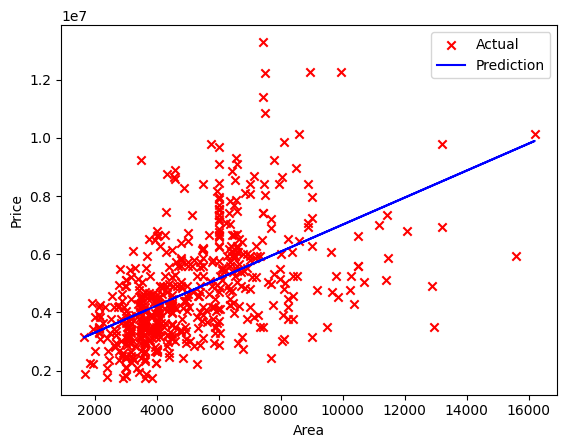

In [40]:
plt.scatter(X, y, marker='x', c='r', label='Actual')
plt.plot(X, w_final*((X - mean)/std) + b_final,
         c='blue', label='Prediction')

plt.xlabel("Area")
plt.ylabel("Price")
plt.legend()
plt.savefig("graphs/Area vs Price Regression Line")
plt.show()

# 10. Prediction

## 10.1 Predict on Test Data

In [41]:
# Predict on Test Data

y_pred = w_final * X_test + b_final
print(y_pred)

436    6.925990e+06
437    4.233768e+06
438    7.130227e+06
439    4.761072e+06
440    3.676756e+06
           ...     
540    4.674735e+06
541    4.010963e+06
542    4.270902e+06
543    4.233768e+06
544    4.062022e+06
Name: area, Length: 109, dtype: float64


## 10.2 Prediction

In [42]:
def predict_price(area):
    area_norm = (area - mean) / std
    prediction = w_final * area_norm + b_final

    print(f"Area: {area} sqft")
    print(f"Predicted Price: {prediction:.2f}")

    actual = df[df["area"] == area]["price"].values

    if len(actual) > 0:
        print("Actual Price(s):", actual)
    else:
        print("No house with this exact area in dataset.")

In [43]:
predict_price(7420)
predict_price(8960)
predict_price(5000)
predict_price(7400)
predict_price(8290)

Area: 7420 sqft
Predicted Price: 5821250.18
Actual Price(s): [13300000 11410000]
Area: 8960 sqft
Predicted Price: 6536081.56
Actual Price(s): [12250000]
Area: 5000 sqft
Predicted Price: 4697943.74
Actual Price(s): [6440000 5740000 5600000]
Area: 7400 sqft
Predicted Price: 5811966.66
No house with this exact area in dataset.
Area: 8290 sqft
Predicted Price: 6225083.49
No house with this exact area in dataset.


# 11. Model Evaluation

## 11.1 Mean Absolute Error(MAEs)

In [44]:
mae = np.mean(np.abs(y_test - y_pred))
print("Mean Absolute Error (MAE):", mae)

Mean Absolute Error (MAE): 1007799.0514218695


## 11.2 Mean Squared Error

In [45]:
mse = np.mean((y_test - y_pred) ** 2)

print("Mean Squared Error (MSE):", mse)

Mean Squared Error (MSE): 1872382149648.1924


## 11.3 Root Mean Square Error(RMSE)

In [46]:
rmse = np.sqrt(mse)

print("Root Mean Squared Error (RMSE):", rmse)

Root Mean Squared Error (RMSE): 1368350.1560814732


## 11.4 R2 Score

In [47]:
ss_total = np.sum((y_test - np.mean(y_test)) ** 2)

ss_residual = np.sum((y_test - y_pred) ** 2)

r2 = 1 - (ss_residual / ss_total)

print("R² Score:", r2)

R² Score: 0.28675420406393193


## Key Finding from Model Evalution
- MAE = 1007799.0514218695 (Because single feature(area))
- MSE = 1872382149648.1924 (Because single feature(area))
- RMSE = 1368350.1560814732 (Because single feature(area))
- R2 = 0.28675420406393193 

- 27% of the price variation is explained by area.
- The remaining 73% is influenced by other features such as:
  - Bedrooms
  - Bathrooms
  - Stories
  - Parking
  - Main Road
  - Air Conditioning
  - Furnishing Status etc.

# 😜 Project Summary

## 👉Conclusion
In this project, I implemented Simple Linear Regression from Scratch to predict house prices using a single feature (Area). Instead of using machine learning libraries, I built the complete algorithm using NumPy, which helped me understand the internal working of Linear Regression.

The project included:

- Data loading and exploration (EDA)
- Data preprocessing
- Feature selection
- Manual train-test split
- Manual feature scaling
- Prediction function
- Cost function (Mean Squared Error)
- Gradient function
- Gradient Descent algorithm
- Model training and prediction
- Model evaluation using MAE, MSE, RMSE, and R² Score

The model achieved an R² Score of approximately 0.27, indicating that around 27% of the variation in house prices is explained by the area feature alone. This shows that while area has a significant impact on house price, it is not sufficient to accurately predict prices because many other factors such as bedrooms, bathrooms, stories, parking, furnishing status, and location-related features also influence the target variable.

Overall, this project provided a strong understanding of how Linear Regression works mathematically and how a machine learning model learns using Gradient Descent. It also highlighted the limitations of using a single feature and motivated the need for Multiple Linear Regression to improve prediction accuracy.

## 📗Key Learning
- Understood the complete workflow of a Machine Learning project.
- Learned how Linear Regression works internally.
- Implemented Prediction, Cost Function, Gradient Function, and Gradient Descent from scratch.
- Performed data preprocessing and feature scaling manually.
- Evaluated model performance using regression metrics.
- Understood the limitations of Simple Linear Regression and the importance of using multiple features.